In [44]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [45]:
RESULT_ROUND_ROBIN = """
                          | Unselfish                 Random                    Greedy                    SlowStarter               Table                     MonteCarlo                MinMax                    NegaMax                   AlphaBeta                 Joseki                    FullReading               Iterative                 Edge                      Switch    
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Unselfish                 | ------                     40.5%                     27.0%                     29.5%                     23.0%                      0.0%                     10.0%                      4.5%                      4.5%                      2.0%                      1.5%                      0.5%                      0.0%                      0.0%    
Random                    |  55.5%                    ------                     35.5%                     31.5%                     24.0%                      0.0%                     11.5%                      7.0%                      3.5%                      6.5%                      0.5%                      0.0%                      0.0%                      0.0%    
Greedy                    |  68.0%                     61.5%                    ------                     45.5%                     38.5%                      0.0%                     13.5%                      7.0%                      5.0%                      4.5%                      1.5%                      0.0%                      0.0%                      0.0%    
SlowStarter               |  67.0%                     67.5%                     52.0%                    ------                     34.5%                      0.0%                     15.5%                      5.5%                      3.0%                      7.0%                      2.0%                      0.0%                      0.0%                      0.0%    
Table                     |  74.0%                     75.0%                     57.0%                     61.5%                    ------                     11.0%                     21.5%                     11.5%                     17.5%                     21.0%                      3.5%                      1.0%                      0.0%                      0.0%    
MonteCarlo                | 100.0%                    100.0%                    100.0%                    100.0%                     87.5%                    ------                     63.0%                     42.5%                     48.0%                     45.5%                     17.0%                      5.0%                      0.0%                      0.0%    
MinMax                    |  87.5%                     86.5%                     83.0%                     81.5%                     76.5%                     31.5%                    ------                     14.0%                     41.5%                     13.5%                     39.0%                      1.0%                      0.0%                      0.0%    
NegaMax                   |  95.0%                     90.0%                     91.5%                     92.5%                     87.5%                     51.0%                     76.0%                    ------                      8.0%                     19.5%                      7.0%                      7.5%                      2.5%                      0.0%    
AlphaBeta                 |  94.0%                     96.0%                     94.0%                     92.5%                     80.5%                     50.0%                     58.5%                     91.5%                    ------                     50.0%                      0.0%                      0.0%                      0.0%                      0.0%    
Joseki                    |  96.5%                     90.5%                     95.5%                     91.5%                     75.5%                     49.0%                     71.5%                     80.5%                     50.0%                    ------                    100.0%                      0.0%                      0.0%                      0.0%    
FullReading               |  98.5%                     99.5%                     98.0%                     97.5%                     96.0%                     80.5%                     61.0%                     80.0%                    100.0%                      0.0%                    ------                      0.0%                      0.0%                      0.0%    
Iterative                 |  99.5%                    100.0%                    100.0%                    100.0%                     98.5%                     94.5%                     99.0%                     92.5%                    100.0%                    100.0%                    100.0%                    ------                     49.0%                      9.0%    
Edge                      | 100.0%                    100.0%                    100.0%                    100.0%                    100.0%                    100.0%                    100.0%                     97.5%                    100.0%                    100.0%                    100.0%                     51.0%                    ------                     52.0%    
Switch                    | 100.0%                    100.0%                    100.0%                    100.0%                    100.0%                    100.0%                    100.0%                    100.0%                    100.0%                    100.0%                    100.0%                     91.0%                     48.0%                    ------    
"""

In [46]:
def create_heatmap(result_round_robin):
    lines = result_round_robin.split("\n")
    
    def get_items(head_line):
        head_line = head_line.split("|")[-1]
        return head_line.split()
    
    # 先頭の不要行を削除
    lines.pop(0)
    header_items = get_items(lines.pop(0))
    lines.pop(0)
    # 末尾の不要行を削除
    lines.pop()
    
    # 表の生データのみ抽出
    row_datas = [l.split("|")[-1].split() for l in lines]

    INVALID = "------"

    def convert(row_value):
        if row_value == INVALID:
            return float(0.5)         # NOTE: RdBuの色指定にしたとき、対角成分を白色にしたいので0.5で設定
        return float(row_value[:-1]) / 100

    heatmap = [[convert(d) for d in row_data] for row_data in row_datas]   

    return heatmap, header_items

In [47]:
heatmap, header_items = create_heatmap(RESULT_ROUND_ROBIN)

In [48]:
heatmap_df = pd.DataFrame(data=heatmap, index=header_items, columns=header_items)
heatmap_df

,Unselfish,Random,Greedy,SlowStarter,Table,MonteCarlo,MinMax,NegaMax,AlphaBeta,Joseki,FullReading,Iterative,Edge,Switch
Unselfish,0.500,0.405,0.270,0.295,0.230,0.000,0.100,0.045,0.045,0.020,0.015,0.005,0.000,0.00
Random,0.555,0.500,0.355,0.315,0.240,0.000,0.115,0.070,0.035,0.065,0.005,0.000,0.000,0.00
Greedy,0.680,0.615,0.500,0.455,0.385,0.000,0.135,0.070,0.050,0.045,0.015,0.000,0.000,0.00
SlowStarter,0.670,0.675,0.520,0.500,0.345,0.000,0.155,0.055,0.030,0.070,0.020,0.000,0.000,0.00
Table,0.740,0.750,0.570,0.615,0.500,0.110,0.215,0.115,0.175,0.210,0.035,0.010,0.000,0.00
MonteCarlo,1.000,1.000,1.000,1.000,0.875,0.500,0.630,0.425,0.480,0.455,0.170,0.050,0.000,0.00
MinMax,0.875,0.865,0.830,0.815,0.765,0.315,0.500,0.140,0.415,0.135,0.390,0.010,0.000,0.00
NegaMax,0.950,0.900,0.915,0.925,0.875,0.510,0.760,0.500,0.080,0.195,0.070,0.075,0.025,0.00
AlphaBeta,0.940,0.960,0.940,0.925,0.805,0.500,0.585,0.915,0.500,0.500,0.000,0.000,0.000,0.00
Joseki,0.965,0.905,0.955,0.915,0.755,0.490,0.715,0.805,0.500,0.500,1.000,0.000,0.000,0.00


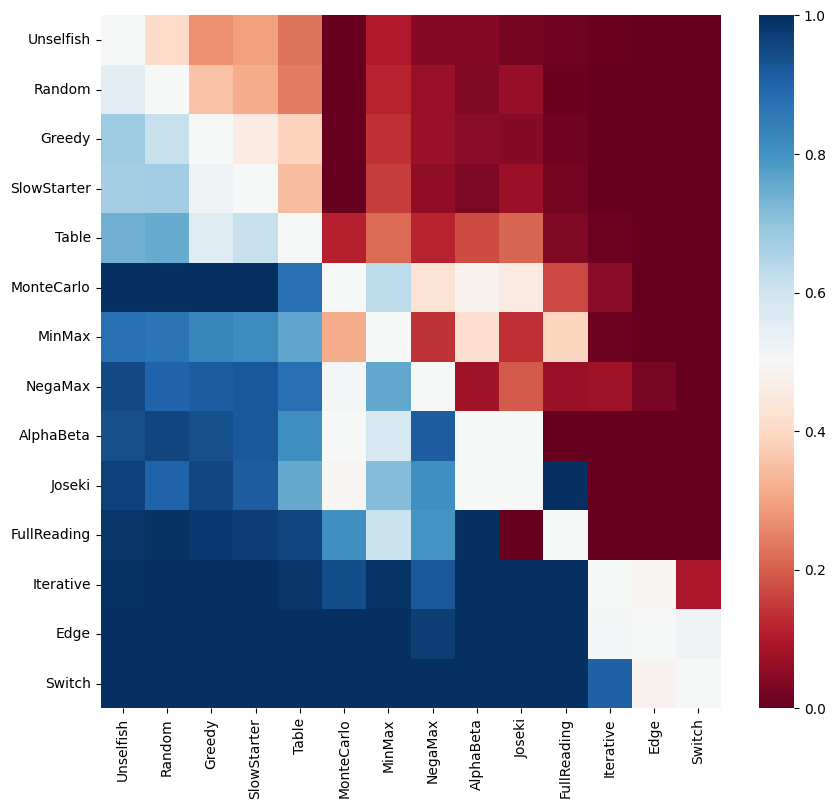

In [52]:
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(heatmap_df, cmap="RdBu")
plt.savefig('win-rate-heatmap_round-robin-match100_.png')